In [2]:
from google.colab import files
uploaded=files.upload()

Saving credit_card_fraud_synthetic.csv to credit_card_fraud_synthetic.csv


In [3]:
import pandas as pd
import numpy as np


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


In [6]:
import plotly.express as px

In [7]:
df = pd.read_csv("credit_card_fraud_synthetic.csv")

In [8]:
print("\nDataset Shape:", df.shape)
print(df.head())



Dataset Shape: (1000, 8)
     Time        V1        V2        V3        V4        V5   Amount  Class
0  121958 -2.289061 -1.313758 -0.452562 -0.392802  0.224787  1600.89      0
1  146867  1.432482 -1.095302 -0.129910 -1.362911 -1.017335  4191.85      0
2  131932  1.214722 -0.168797  0.581433  0.699020  0.964415  3271.32      0
3  103694 -0.880864  0.110956 -0.203236 -0.243510  0.362543  1377.51      0
4  119879 -0.881879  0.786970  1.110118  0.015365 -1.135162  4838.72      0


In [9]:
print("\nMissing Values:\n", df.isnull().sum())



Missing Values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
Amount    0
Class     0
dtype: int64


In [10]:
df = df.drop_duplicates()

In [11]:
print("\nAfter removing duplicates:", df.shape)


After removing duplicates: (1000, 8)


In [12]:
print("\nDescription:\n", df.describe())


Description:
                 Time           V1           V2           V3           V4  \
count    1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean    86194.539000     0.017610     0.069906    -0.022792     0.022354   
std     50008.474586     1.038301     1.035560     0.992346     0.978387   
min       235.000000    -3.568205    -2.913672    -3.239438    -2.936162   
25%     42052.250000    -0.646795    -0.594730    -0.693360    -0.624690   
50%     89361.500000     0.031403     0.089010    -0.008512    -0.000167   
75%    127614.750000     0.742573     0.759734     0.666350     0.664478   
max    172627.000000     3.174442     3.260491     2.750723     3.657702   

                V5       Amount        Class  
count  1000.000000  1000.000000  1000.000000  
mean     -0.013218  2577.052080     0.018000  
std       0.998908  1444.284318     0.133018  
min      -3.708797    25.890000     0.000000  
25%      -0.711692  1358.502500     0.000000  
50%       0.019587

In [13]:
print("\nClass Count:\n", df['Class'].value_counts())


Class Count:
 Class
0    982
1     18
Name: count, dtype: int64


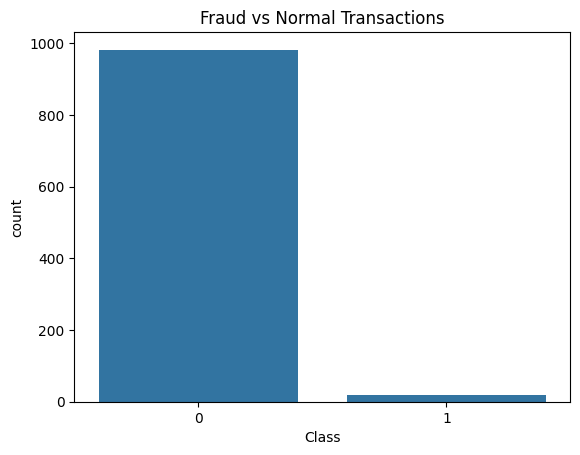

In [14]:

sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

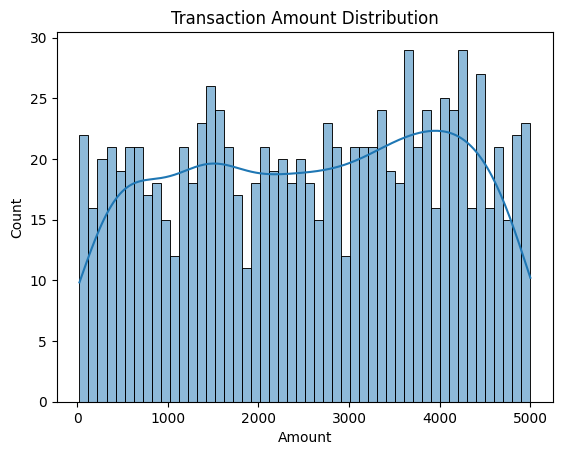

In [15]:
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

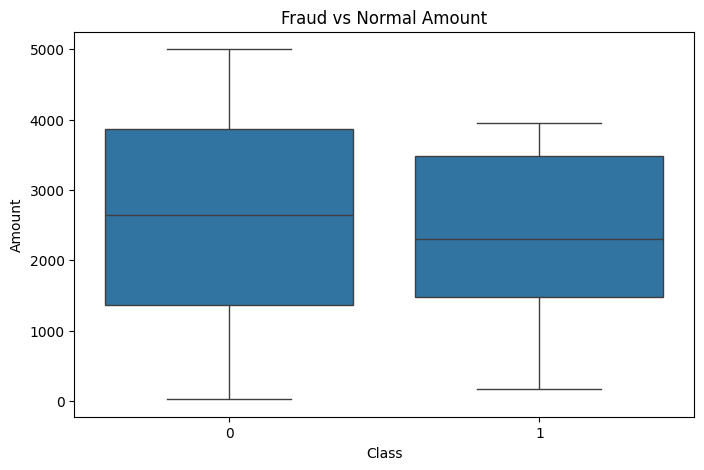

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Fraud vs Normal Amount")
plt.show()

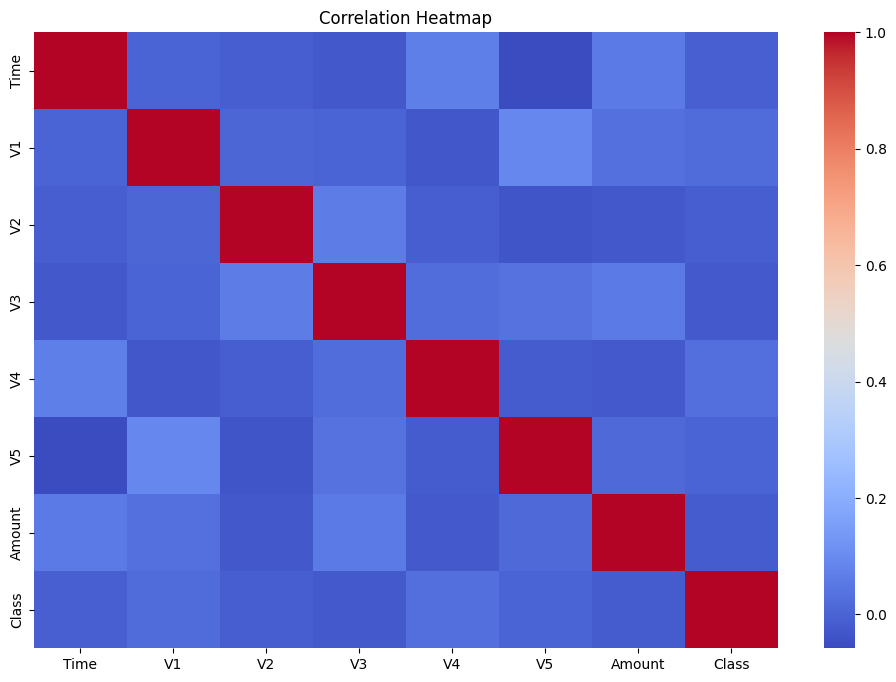

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [18]:
def risk_level(amount):
    if amount < 50:
        return "Low Risk"
    elif amount < 200:
        return "Medium Risk"
    else:
        return "High Risk"


In [19]:

df['Risk'] = df['Amount'].apply(risk_level)

In [20]:

print(df[['Amount','Risk']].head())

    Amount       Risk
0  1600.89  High Risk
1  4191.85  High Risk
2  3271.32  High Risk
3  1377.51  High Risk
4  4838.72  High Risk


In [21]:
X = df[['Time', 'Amount']]
y = df['Class']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [23]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [24]:
y_pred = model.predict(X_test)


In [25]:
print("\nR2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


R2 Score: -0.003785680897719468
MSE: 0.019674199345595292


In [26]:
fraud = df[df['Class'] == 1].shape[0]
normal = df[df['Class'] == 0].shape[0]

In [27]:
print("\nFraud Transactions:", fraud)
print("Normal Transactions:", normal)
print("Fraud Percentage:", fraud / len(df) * 100)


Fraud Transactions: 18
Normal Transactions: 982
Fraud Percentage: 1.7999999999999998


In [28]:
import plotly.io as pio
pio.renderers.default = "colab"

In [34]:
fig1 = px.histogram(df, x='Class', color='Class',
                    title="Fraud vs Normal Transactions")
fig1.show()


In [35]:
fig2 = px.scatter(df, x='Time', y='Amount', color='Class',
                  title="Time vs Transaction Amount")
fig2.show()

In [36]:
fig3 = px.histogram(df, x='Risk', color='Risk',
                    title="Transaction Risk Levels")
fig3.show()

In [39]:
fig4 = px.imshow(df.drop(columns=['Risk']).corr(),
                 title="Correlation Heatmap")
fig4.show()

In [40]:
print("\nProject Completed Successfully 🚀")


Project Completed Successfully 🚀
